# 📓 KNN con diferentes distancias y visualización

En este notebook aprenderás:
- Qué es KNN
- Cómo cambian las distancias
- Cómo elegir el mejor K
- Visualizar fronteras de decisión

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


## 📊 Cargar dataset

In [5]:
iris = load_iris()
X = iris.data[:, :2]  # solo 2 features para graficar
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## KNN Manual, intuición matemática

In [ ]:
def knn_manual(X, y, x_new, k=3):
# Crea la función
    distancia = np.linalg.norm(X-x_new, axis=1)  
    # Organizar por distancia 
    # Seleccionar los k vecinos más cercanos (X los datos mas cercanos)
    k_ind = np.argsort(distancia)[:k]
    # moda de las etiquetas de los vecinos más cercanos
    etiquetas_k_vecinos = y[k_ind]
    
    counter = Counter(etiquetas_k_vecinos).most_common(1)
    return counter[0][0]

    # return la etiqueta predicha


y_pred = np.array([knn_manual(X_train, y_train, x, k=3) for x in X_test])

print(y_pred)

[1 0 2 1 1 0 1 2 1 2 2 0 0 0 0 2 2 1 2 2 0 1 0 2 2 1 2 2 0 0]


In [17]:
class KNNManual:

    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict_one_value(self, x_new):
        distancia = np.linalg.norm(self.X_train-x_new, axis=1)  
        k_ind = np.argsort(distancia)[:self.k]
        etiquetas_k_vecinos = self.y_train[k_ind]    
        counter = Counter(etiquetas_k_vecinos).most_common(1)
        return counter[0][0]

    def predict(self, X):
        return np.array([self.predict_one_value(x) for x in X])
          



In [18]:
modelo_knn = KNNManual(k=3)
modelo_knn.fit(X_train, y_train)
y_pred_manual = modelo_knn.predict(X_test)  
print(y_pred_manual)

[1 0 2 1 1 0 1 2 1 2 2 0 0 0 0 2 2 1 2 2 0 1 0 2 2 1 2 2 0 0]


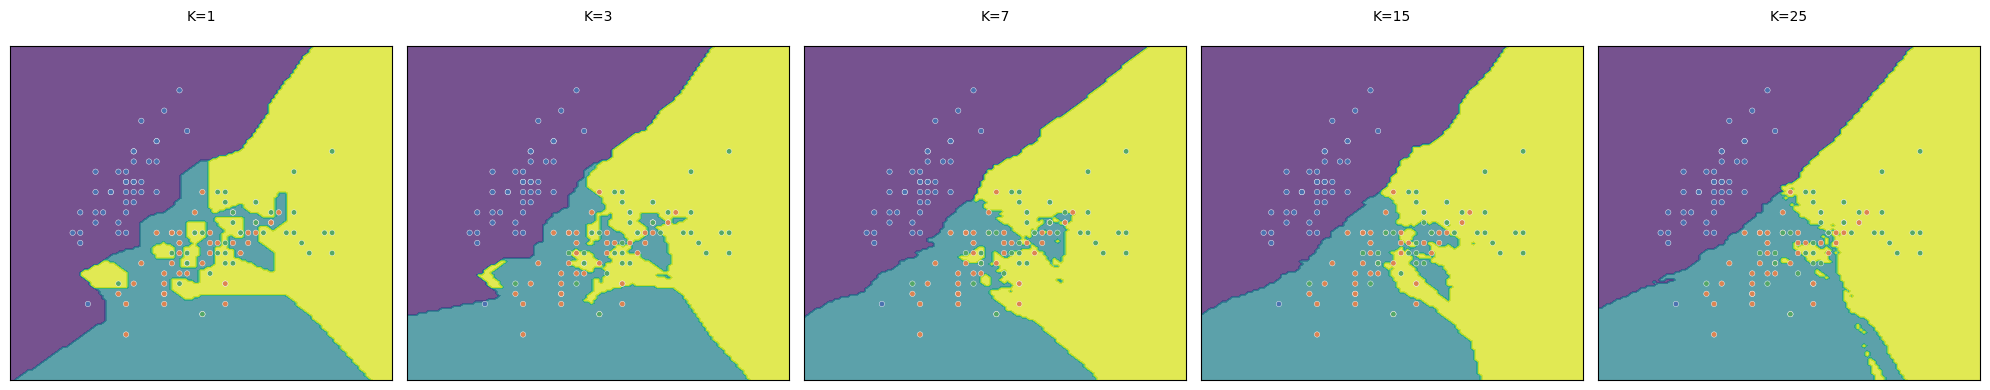

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
COLORS     = ['#4C72B0', '#DD8452', '#55A868']

for ax, k in zip(axes, [1, 3, 7, 15, 25]):
    knn = KNNManual(k=k)
    knn.fit(X_train, y_train)

    h = 0.05
    x0_min, x0_max = X_train[:,0].min()-1, X_train[:,0].max()+1
    x1_min, x1_max = X_train[:,1].min()-1, X_train[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.75)
    ax.scatter(X_train[:,0], X_train[:,1], c=[COLORS[c] for c in y_train],
               s=15, edgecolors='white', linewidths=0.3)
    
    ax.set_title(f'K={k}\n', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## 📏 Entrenar modelos con diferentes distancias

In [23]:
metrics = ['euclidean', 'manhattan', 'cosine']

for metric in metrics:
    model = KNeighborsClassifier(n_neighbors=5, metric=metric)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{metric}:", accuracy_score(y_test, preds))


euclidean: 0.7666666666666667
manhattan: 0.7666666666666667
cosine: 0.7333333333333333


## 🔍 Encontrar mejor K

In [25]:
param_grid = {
    'n_neighbors': np.arange(1, 21),
    'metric': ['euclidean', 'manhattan', 'cosine']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print('Mejores parámetros:', grid.best_params_)


# ver todos los resultados
results = pd.DataFrame(grid.cv_results_)

Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': np.int64(18)}


In [31]:
results["1-acc"] = 1. - results['mean_test_score']
results.sort_values('mean_test_score', ascending=False)[['param_n_neighbors', 'param_metric', 'mean_test_score']]

,param_n_neighbors,param_metric,mean_test_score
17,18,euclidean,0.791667
37,18,manhattan,0.783333
39,20,manhattan,0.783333
38,19,manhattan,0.783333
19,20,euclidean,0.775000
18,19,euclidean,0.775000
16,17,euclidean,0.766667
15,16,euclidean,0.766667
23,4,manhattan,0.758333
34,15,manhattan,0.758333


<Axes: xlabel='param_n_neighbors', ylabel='1-acc'>

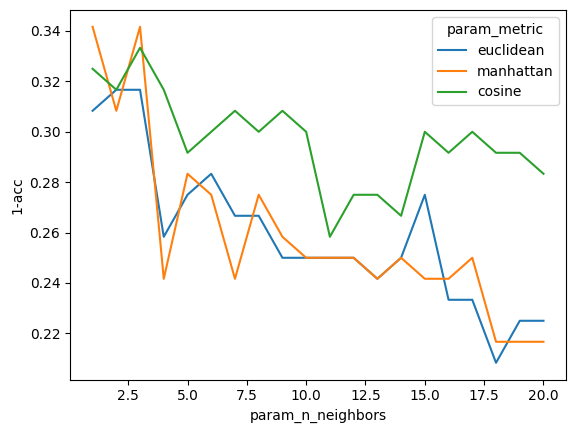

In [33]:
sns.lineplot(data=results, x='param_n_neighbors', y="1-acc", hue='param_metric')


## 📈 Visualización de frontera de decisión

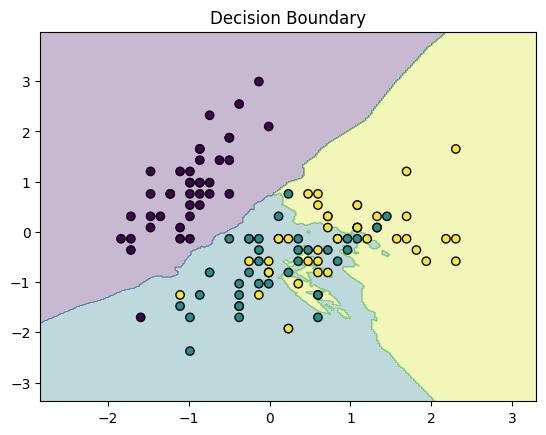

In [34]:
def plot_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title('Decision Boundary')
    plt.show()

best_model = grid.best_estimator_
plot_decision_boundary(best_model, X_train, y_train)


## 📌 Aplicaciones de KNN

- Sistemas de recomendación
- Clasificación de imágenes
- Detección de fraude
- NLP (clasificación de texto)

### ⚠️ Limitaciones
- No escala bien
- Sensible al escalado
- Lento en predicción

### 🤖 Modelos relacionados
- K-Means
- DBSCAN
- Nearest Centroid
- Approximate Nearest Neighbors
